# 3. Regression (Continuous Values)
Jab target koi continuous number ho (Jaise tumhara student marks predictor ya California house price predictor). Yahan Accuracy ya Confusion Matrix **kaam nahi aate** kyunke yahan Yes/No nahi hota.

## 🔢 Metrics (Numbers):

MAE (Mean Absolute Error): Jaisa tumhari notes file mein likha hai. Yeh batata hai ke model ki prediction asal value se average kitni door hai (e.g., Ghar ki qeemat mein model average $5000 ki ghalti kar raha hai).

MSE (Mean Squared Error) / RMSE: Ghaltiyon ko square karta hai, jis se bari ghaltiyan (outliers) zyada highlight hoti hain.

R-Squared ($R^2$ Score): Yeh 0 se 1 ke darmiyan hota hai. Batata hai ke model ne data ka kitna variance capture kiya hai (80% $R^2$ bohot acha mana jata hai).

## 📊 Graphs (Visuals):

Actual vs Predicted Scatter Plot: Ek seedhi line (diagonal) banti hai. Agar points us line ke qareeb hain, toh model best hai.

Residual Plot: Yeh graph ghaltiyon (residuals) ka banta hai taake dekha ja sake ke model kisi khaas range mein zyada ghalti toh nahi kar raha.

## import required libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("C:\\Deep Learning (Campus X)\\keras & ANN by campus x\\projects\\medical_insurance.csv")
print(df.head())
df_original = df.copy()

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [4]:

print('-'*50)
print('columns of this dataset :')
print(df.columns)
print('-'*50)

--------------------------------------------------
columns of this dataset :
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')
--------------------------------------------------


In [5]:
df['region'].unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [6]:

print('-'*50)
print('Info of this dataset :')
print(df.info())
print('-'*50)

--------------------------------------------------
Info of this dataset :
<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB
None
--------------------------------------------------


In [7]:
print('-'*50)
print('statistical summary of this dataset :')
print(df.describe())
print('-'*50)

--------------------------------------------------
statistical summary of this dataset :
               age          bmi     children       charges
count  2772.000000  2772.000000  2772.000000   2772.000000
mean     39.109668    30.701349     1.101732  13261.369959
std      14.081459     6.129449     1.214806  12151.768945
min      18.000000    15.960000     0.000000   1121.873900
25%      26.000000    26.220000     0.000000   4687.797000
50%      39.000000    30.447500     1.000000   9333.014350
75%      51.000000    34.770000     2.000000  16577.779500
max      64.000000    53.130000     5.000000  63770.428010
--------------------------------------------------


In [8]:
print('-'*50)
print('check empty columns :')
print(df.isnull().sum())
print('-'*50)

--------------------------------------------------
check empty columns :
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
--------------------------------------------------


## Check Outliers

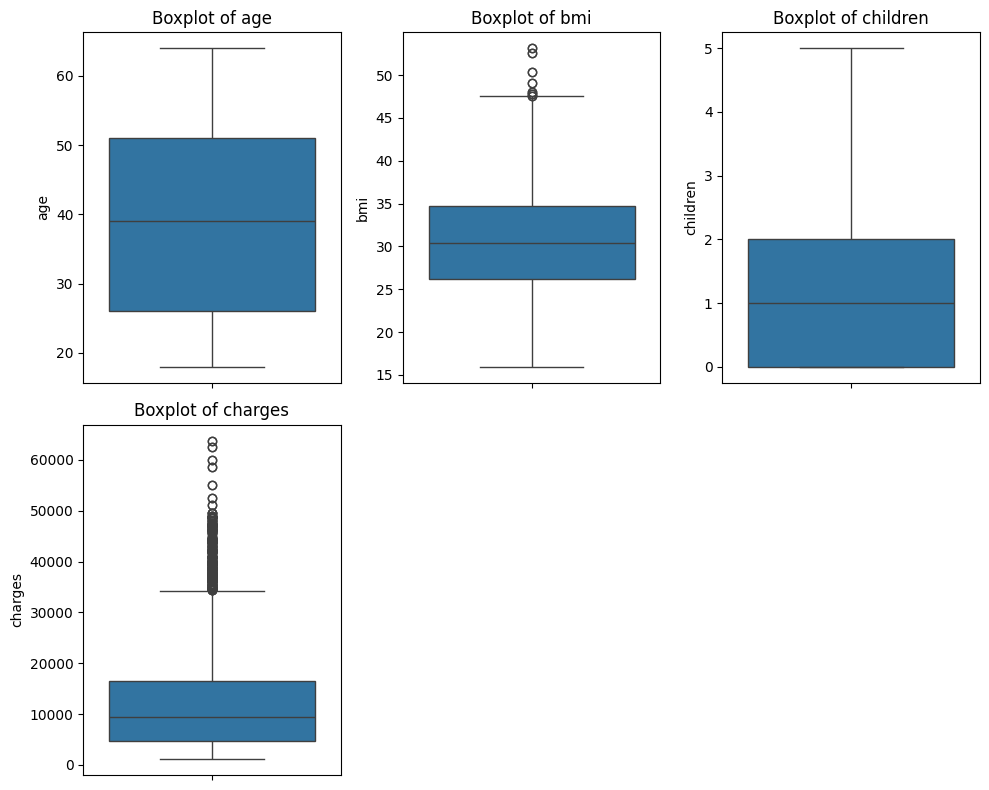

In [9]:
# apply loop for crearing box plot of 4 columns 
cols_to_box_plot = ['age' , 'bmi' , 'children' , 'charges']

plt.figure(figsize=(10,8))

for i , col in enumerate(cols_to_box_plot) :
    plt.subplot(2,3,i+1) # set grid (2 rows 3 columns)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Remove Outliers

In [10]:

# we found outliers in 2 column 
# we will apply iqr capping on bmi 

def apply_iqr_capping(df, column):
    # calculate quantile
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # calculate IQR
    IQR = Q3 - Q1

    # set boundries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # if the value is greater than uper bound , make it upper bound
    # if the value is less than lower bound , make it lower bound
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])

    print(f'Capping successful for column {column}')
    print(f'Lower Bound : {lower_bound:.2f}, Upper Bound : {upper_bound:.2f}')

    return df

# Apply on Bmi Column
apply_iqr_capping(df, 'bmi')

# Verification: Ab koi value Upper Bound se bari nahi hogi
print(f"\nMax Bmi After Capping : {df['bmi'].max() :.2f}")

Capping successful for column bmi
Lower Bound : 13.39, Upper Bound : 47.60

Max Bmi After Capping : 47.60


## Log Trasformation

In [11]:
df['charges'] = np.log1p(df['charges'])

# Encoding

In [13]:
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])

# one hot encoding 
df_encoded = pd.get_dummies(df , columns=['region'] , drop_first=True , dtype=int)
print(df_encoded)

      age  sex     bmi  children  smoker   charges  region_northwest  \
0      19    0  27.900         0       1  9.734236                 0   
1      18    1  33.770         1       0  7.453882                 0   
2      28    1  33.000         3       0  8.400763                 0   
3      33    1  22.705         0       0  9.998137                 1   
4      32    1  28.880         0       0  8.260455                 1   
...   ...  ...     ...       ...     ...       ...               ...   
2767   47    0  45.320         1       0  9.056124                 0   
2768   21    0  34.600         0       0  7.611435                 0   
2769   19    1  26.030         1       1  9.708196                 1   
2770   23    1  18.715         0       0  9.980281                 1   
2771   54    1  31.600         0       0  9.195372                 0   

      region_southeast  region_southwest  
0                    0                 1  
1                    1                 0  
2     

In [17]:
df_encoded.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')

## Explorartory Data Anlysis

#### Scatter plot

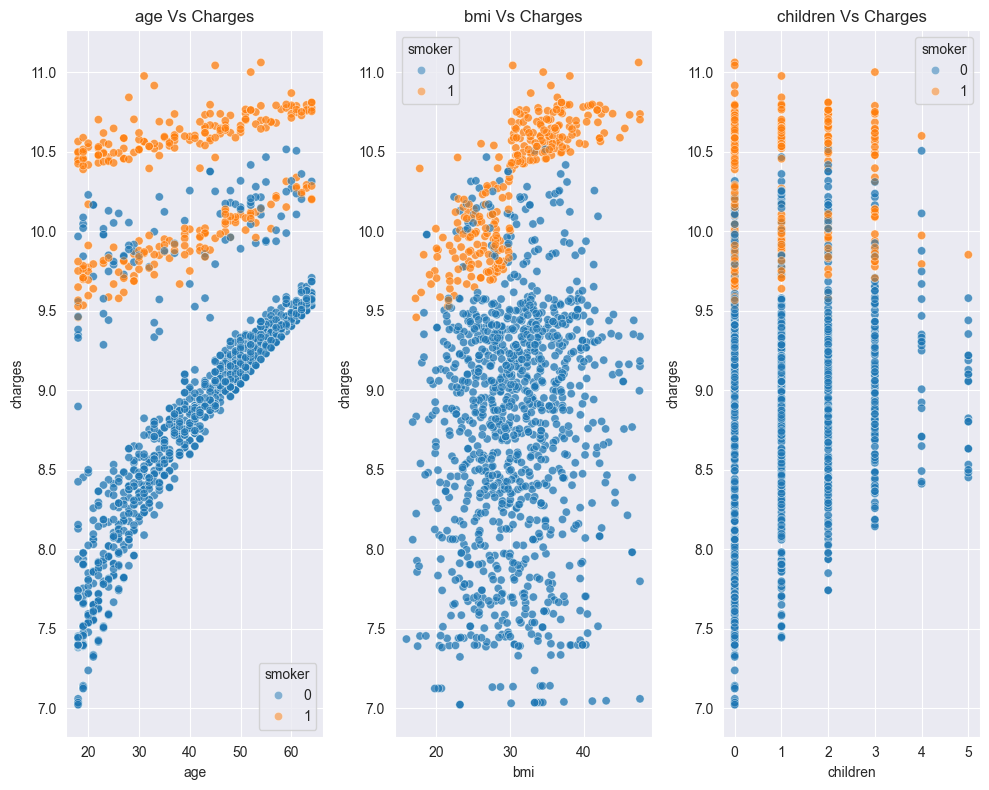

In [353]:
cols_to_scatter_plot = ['age' , 'bmi' , 'children']
plt.figure(figsize=(10,8))

for i, col in enumerate(cols_to_scatter_plot):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df[col], y=df['charges'], alpha=0.5, hue=df['smoker'])
    plt.title(f'{col} Vs Charges')

plt.tight_layout()
plt.show()

#### Heatmap

<Axes: >

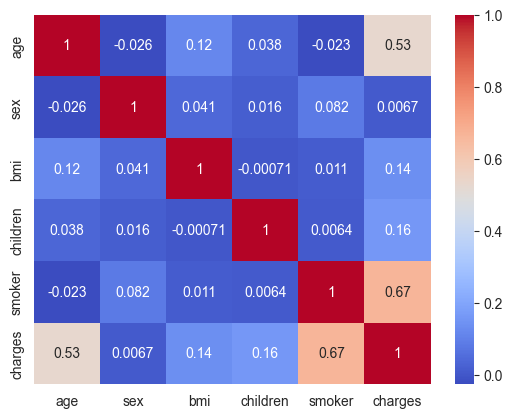

In [354]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

## Horizontal bar plot

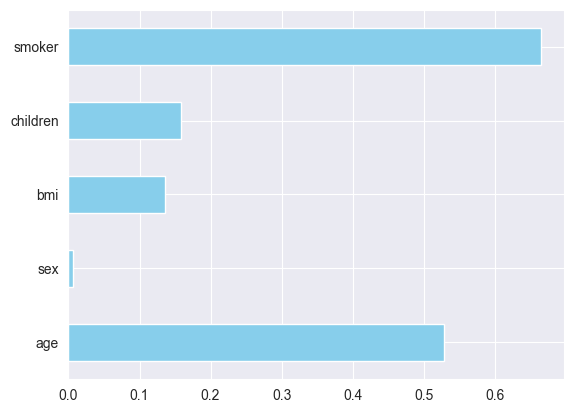

In [355]:
corr_barh = numeric_df.corr()['charges'].drop('charges')
corr_barh.plot(kind='barh', color='skyblue')
plt.show()

## Boxplot

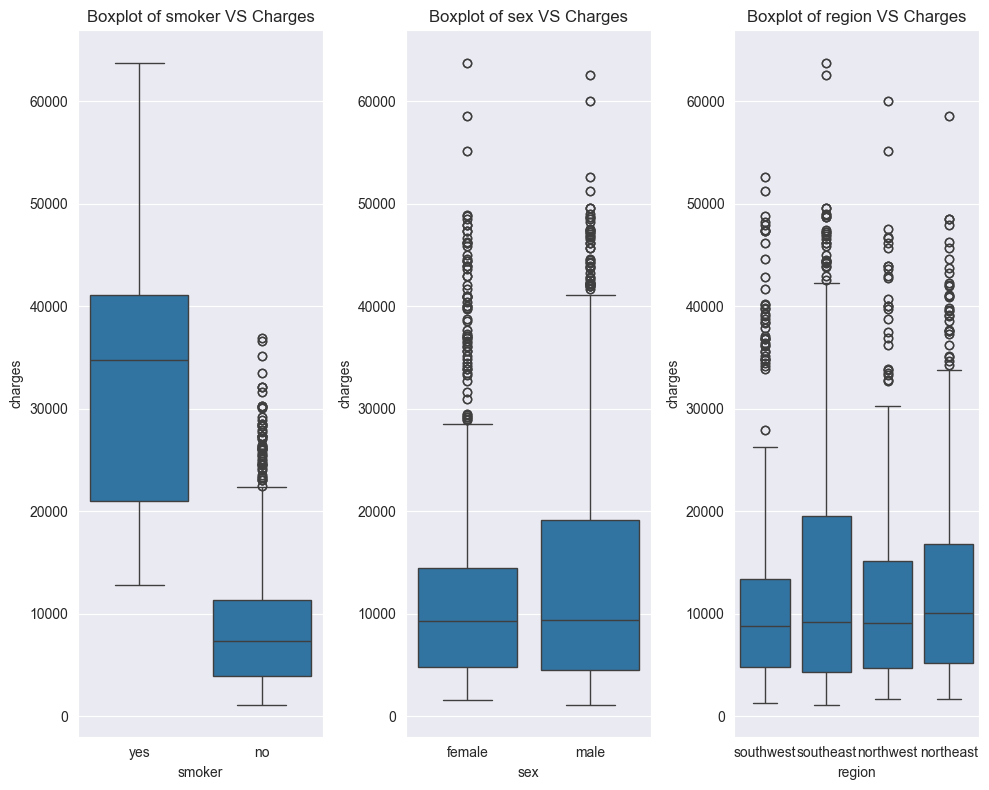

In [356]:
cat_cols_to_boxplot = ['smoker','sex','region']
plt.figure(figsize=(10,8))
for i , col in enumerate(cat_cols_to_boxplot):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=df_original[col] , y=df_original['charges'])
    plt.title(f'Boxplot of {col} VS Charges')
plt.tight_layout()
plt.show()

## Feature Engineering
adding new feature

In [357]:
df_encoded['smoker_bmi_interaction'] = df['smoker'] * df['bmi']
df_encoded['high_risk_smoker'] = np.where((df['smoker'] == 1) & (df['bmi'] > 30), 1, 0)

In [358]:
df_encoded.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'smoker_bmi_interaction', 'high_risk_smoker'],
      dtype='str')

------

# seprarate features

In [359]:
X = df_encoded.drop(columns='charges')
y = df_encoded['charges']

In [360]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

### Feature scaling

In [361]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Newral network Architecture

In [362]:
import keras 
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras import regularizers

1. model with **batch normalization** = 85 percent pattern, mse = 0.14 
2. model with **batch normalization and dropout** = 82 percent pattern  , mse=0.16
3. model with **batch normalization and dropout and early stopping** = 82 percent pattern , 0.17
4. model with **batch normalization and early stopping** = 83 percent pattern,  mse=0.15
5. model with **batch normalization and kernal regularizer l2** = 81 percent pattern, mse = 0.20

In [363]:
# model initialize
model = Sequential()

# first hidden layer                                                                                        
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],),
                kernel_initializer='he_normal',    # kernel initializer for getting best results
                #kernel_regularizer=regularizers.l2(0.01)   #kernel_regularizer=regularizers.l2(0.01) for prevent overfitting
                ))  
model.add(BatchNormalization())  # for output scaling
#model.add(Dropout(0.3)) # ye 30 percent neurons ko band ker de ga , jis se overfitting nai ho gi 

# second hidden layer
model.add(Dense(units=32, activation='relu', 
                kernel_initializer='he_normal',
                #kernel_regularizer=regularizers.l2(0.01)
                ))
model.add(BatchNormalization())
#model.add(Dropout(0.3))

# third hidden layer
model.add(Dense(units=16, activation='relu', 
                kernel_initializer='he_normal',
                #kernel_regularizer=regularizers.l2(0.01)
                ))
model.add(BatchNormalization())
#model.add(Dropout(0.2))

# output layer
model.add(Dense(units=1, activation='linear'))

c:\Users\rafay_hk\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## ⚡ Rule of Thumb
* Start with **0.2–0.3** for each hidden layer.

* Agar **training accuracy** bahut high hai lekin **validation accuracy** low hai **(overfitting)**, dropout ko thoda increase karo (0.4–0.5).

* Agar training slow ho raha hai ya **underfitting** lag raha hai, dropout ko reduce karo (0.1–0.2).

In [364]:
# for getting model summary
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,553 (13.88 KB)

 Non-trainable params: 224 (896.00 B)

# Compilation

In [365]:
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mape', keras.metrics.RootMeanSquaredError()])

# EarlyStop

In [366]:
# for prevents overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    mode='min',
    min_delta=0.001,
    patience=15,
    start_from_epoch=5,
    restore_best_weights=True,
    verbose=1
)

# fitting

In [367]:
history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test_scaled, y_test),
    #callbacks=[early_stop],
    verbose=1 
)

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 80.0347 - mae: 8.9074 - mape: 98.4334 - root_mean_squared_error: 8.9462 - val_loss: 72.2137 - val_mae: 8.4742 - val_mape: 94.7349 - val_root_mean_squared_error: 8.4979
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 69.7929 - mae: 8.3293 - mape: 92.1875 - root_mean_squared_error: 8.3542 - val_loss: 63.1031 - val_mae: 7.9235 - val_mape: 88.7228 - val_root_mean_squared_error: 7.9437
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 55.6970 - mae: 7.4331 - mape: 82.2456 - root_mean_squared_error: 7.4630 - val_loss: 49.0576 - val_mae: 6.9837 - val_mape: 78.2447 - val_root_mean_squared_error: 7.0041
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39.7086 - mae: 6.2608 - mape: 69.2301 - root_mean_squared_error: 6.3015 - val_loss: 32.3638 - val_mae: 5.6664 - val_mape: 63.3995 - val_root_mean_squared_error: 5.6889
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24.7215 - mae: 4.9207 - mape: 54.

## Final Loss

In [368]:
# for getting final loss 
loss_mse, mae, mape, rmse = model.evaluate(X_test_scaled, y_test)


print(f'Test Loss (MSE): {loss_mse}')
print(f'Test MAE: {mae}')
print(f'Test MAPE: {mape}')
print(f'Test RMSE: {rmse}')

'''
# 2. Results ko unke index ke hisaab se print karein
results = model.evaluate(X_test_scaled, y_test)

print(f'Test Loss (MSE): {results[0]:.4f}')

print(f'Test MAE: {results[1]:.4f}')

print(f'Test MAPE: {results[2]:.2f}%')

print(f'Test RMSE: {results[3]:.4f}')
'''

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1412 - mae: 0.2110 - mape: 2.3386 - root_mean_squared_error: 0.3757 
Test Loss (MSE): 0.14118584990501404
Test MAE: 0.21103045344352722
Test MAPE: 2.338582992553711
Test RMSE: 0.37574705481529236


"\n# 2. Results ko unke index ke hisaab se print karein\nresults = model.evaluate(X_test_scaled, y_test)\n\nprint(f'Test Loss (MSE): {results[0]:.4f}')\n\nprint(f'Test MAE: {results[1]:.4f}')\n\nprint(f'Test MAPE: {results[2]:.2f}%')\n\nprint(f'Test RMSE: {results[3]:.4f}')\n"

In [369]:
y_pred = model.predict(X_test_scaled)
score = r2_score(y_test, y_pred)

print(f'R_2 Score : {score}')

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
R_2 Score : 0.8497366144041478


In [370]:
train_predictions = model.predict(X_train_scaled)
test_predictions = model.predict(X_test_scaled)

# 5. R-squared (R2) score calculate karna (Yeh Regression ki accuracy hoti hai)
train_accuracy = r2_score(y_train, train_predictions)
test_accuracy = r2_score(y_test, test_predictions)

# 6. Results ko percentage (%) mein print karna
print(f"Accuracy (R2 Score) On Training Data: {train_accuracy * 100:.2f}%")
print(f"Accuracy (R2 Score) On Testing Data: {test_accuracy * 100:.2f}%")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step
Accuracy (R2 Score) On Training Data: 90.26%
Accuracy (R2 Score) On Testing Data: 84.97%


## For getting weights 

In [371]:
# weights of first hidden layer
model.layers[0].get_weights()

[array([[ 1.36452541e-01,  2.97865540e-01, -8.78418386e-01,
          1.16065003e-01, -1.21863298e-01,  6.81229591e-01,
          7.55407274e-01,  2.98034370e-01,  2.90539348e-03,
         -9.27740633e-01,  9.63914394e-01, -7.17311740e-01,
         -3.44407380e-01,  1.86598927e-01,  7.45316207e-01,
          2.53518671e-01, -1.31745741e-01, -4.64152008e-01,
          4.79475081e-01,  2.00599730e-01,  4.70371842e-01,
          5.27842164e-01, -1.92428246e-01,  5.08822322e-01,
          4.83716697e-01, -5.77475190e-01,  3.08794171e-01,
          9.91493523e-01, -7.31847644e-01,  5.56659639e-01,
          4.00313675e-01,  6.00039482e-01,  2.78949976e-01,
         -5.33096194e-01, -8.95469263e-02,  2.79795676e-01,
         -1.22595675e-01, -6.26453519e-01,  2.07210287e-01,
         -9.16794717e-01,  3.70179981e-01, -6.60452485e-01,
          1.99890539e-01, -2.70932078e-01,  3.43798697e-01,
         -7.32059717e-01,  3.79071236e-01,  8.44850838e-02,
          1.23341925e-01, -1.45665228e-0

In [372]:
# weights of second hidden layer
model.layers[1].get_weights()

[array([0.89762735, 0.82654774, 1.2813685 , 1.1691972 , 0.8729867 ,
        1.2577462 , 0.9658257 , 0.89254683, 1.039075  , 1.0351222 ,
        0.8805916 , 1.0131464 , 0.93139553, 1.0070466 , 1.0426953 ,
        0.93806267, 0.82400393, 0.91230816, 0.8189418 , 0.9247007 ,
        1.1451932 , 1.0114098 , 1.000582  , 0.9221384 , 0.9440172 ,
        1.0404433 , 1.1979082 , 1.0207089 , 0.99899036, 0.91281253,
        1.0168403 , 1.0258474 , 1.0662776 , 0.93578374, 1.01744   ,
        0.9466672 , 0.97052383, 0.8778885 , 1.1131399 , 0.88690245,
        1.1861818 , 0.9304741 , 1.0385659 , 0.87834847, 0.82772774,
        0.9533519 , 0.930746  , 0.93888664, 0.9350504 , 1.0290457 ,
        1.0167735 , 0.935767  , 1.1291937 , 0.77494776, 1.338218  ,
        1.1179361 , 1.0112994 , 0.96578497, 0.8898467 , 1.0831922 ,
        1.2008173 , 1.1211383 , 0.88954926, 0.8978323 ], dtype=float32),
 array([-0.12807508,  0.14401414,  0.05837877,  0.01728498,  0.07848503,
         0.02431477, -0.05361035,  0.0

In [373]:
# weights of third hidden layer
model.layers[2].get_weights()

[array([[ 0.21538824,  0.07712024,  0.25466427, ...,  0.03125483,
         -0.41408   ,  0.03020127],
        [ 0.05295835, -0.03452756,  0.01106803, ..., -0.21814303,
          0.01457368, -0.06456818],
        [-0.10369521,  0.2867003 , -0.1438762 , ...,  0.27709106,
          0.05665036,  0.11168121],
        ...,
        [-0.01608399, -0.13893484, -0.45940423, ..., -0.01054635,
          0.02233921, -0.21072929],
        [ 0.2352947 , -0.13714759,  0.02879591, ...,  0.10639615,
         -0.13703312, -0.05296671],
        [ 0.06190843, -0.29400945, -0.09300578, ..., -0.21198878,
          0.09705716,  0.01749102]], shape=(64, 32), dtype=float32),
 array([-0.03876309, -0.17872137,  0.00266304,  0.1641816 , -0.00407149,
         0.23479146,  0.06925474,  0.0276882 , -0.00580322, -0.00811879,
        -0.00846902, -0.06339765,  0.05781597, -0.04090097,  0.19568816,
         0.08002741,  0.14532398, -0.05215972, -0.00599265, -0.16672733,
        -0.19259213,  0.0805871 , -0.06648088,  0.

### Plot between train loss and validation loss

C:\Users\rafay_hk\AppData\Local\Temp\ipykernel_10072\3868287917.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


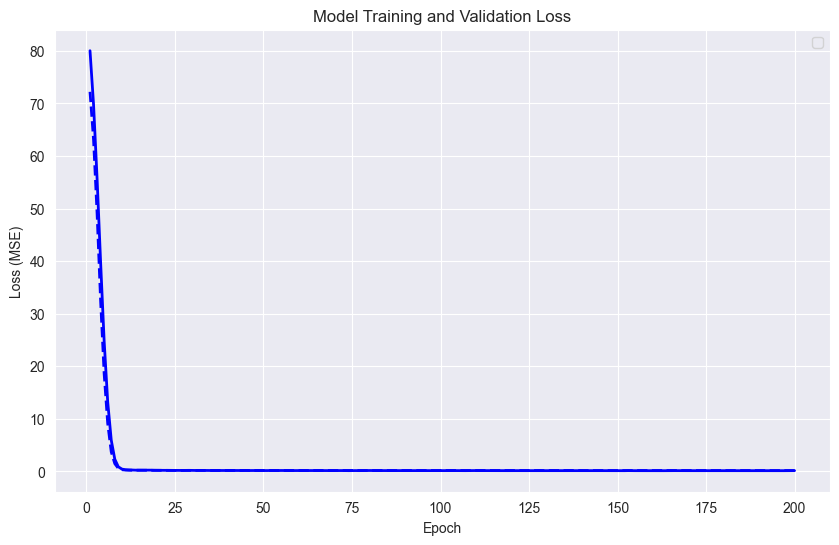

In [374]:
sns.set_style('darkgrid')

train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# plotting graph
plt.figure(figsize=(10,6))
plt.plot(epochs, train_loss, color='blue', linewidth=2)
plt.plot(epochs, val_loss, color='blue', linewidth=2, linestyle='--')

plt.title('Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [375]:
import joblib

# 1. Scaler ko disk par save karna
# (Ensure karna ke 'scaler' wohi variable hai jis se tumne X_train fit kiya tha)
joblib.dump(scaler, 'insurance_scaler.joblib')
print("Scaler successfully saved as insurance_scaler.joblib")

# 2. Keras ANN Model ko save karna
model.save('medical_insurance_model.keras')
print("Model successfully saved as medical_insurance_model.keras")

Scaler successfully saved as insurance_scaler.joblib
Model successfully saved as medical_insurance_model.keras


-----

# FastAPI Backend Code (main.py)

In [ ]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
import joblib
from keras.models import load_model

# 1. API Initialize karna
app = FastAPI(
    title="Medical Insurance Cost Predictor API",
    description="Deep Learning model to predict medical insurance charges based on patient data.",
    version="1.0"
)

# 2. Model aur Scaler ko memory mein load karna (Global scope taake har request par dobara load na ho)
try:
    model = load_model('medical_insurance_model.keras')
    scaler = joblib.load('insurance_scaler.joblib')
    print("Model and Scaler loaded successfully!")
except Exception as e:
    print(f"Error loading model/scaler: {e}")

# 3. Pydantic Model (Data Validation ke liye)
# Ye ensure karega ke user api ko sahi format mein data bhej raha hai
class PatientData(BaseModel):
    age: int
    sex: str
    bmi: float
    children: int
    smoker: str
    region: str

# 4. Prediction Endpoint
@app.post("/predict")
def predict_charges(data: PatientData):
    try:
        # --- A. Data Extraction & Encoding ---
        sex_encoded = 1 if data.sex.lower() == 'male' else 0
        smoker_encoded = 1 if data.smoker.lower() == 'yes' else 0
        
        region_northwest = 1 if data.region.lower() == 'northwest' else 0
        region_southeast = 1 if data.region.lower() == 'southeast' else 0
        region_southwest = 1 if data.region.lower() == 'southwest' else 0
        
        # --- B. Feature Engineering (On-the-fly) ---
        smoker_bmi_interaction = smoker_encoded * data.bmi
        high_risk_smoker = 1 if (smoker_encoded == 1 and data.bmi > 30) else 0

        # --- C. Array Assembly ---
        # Order MUST match training data exactly
        input_features = np.array([[
            data.age, sex_encoded, data.bmi, data.children, smoker_encoded, 
            region_northwest, region_southeast, region_southwest, 
            smoker_bmi_interaction, high_risk_smoker
        ]])
        
        # --- D. Scaling ---
        scaled_features = scaler.transform(input_features)
        
        # --- E. Model Prediction ---
        log_prediction = model.predict(scaled_features)[0][0]
        
        # --- F. Inverse Log Transform ---
        final_charge = np.expm1(log_prediction)
        
        # JSON response return karna
        return {
            "status": "success",
            "patient_profile": {
                "age": data.age,
                "bmi": data.bmi,
                "smoker": data.smoker
            },
            "predicted_insurance_charge": round(float(final_charge), 2)
        }

    except Exception as e:
        # Agar koi code phat jaye, toh proper error return karein
        raise HTTPException(status_code=400, detail=str(e))

# Root endpoint check karne ke liye API zinda hai ya nahi
@app.get("/")
def read_root():
    return {"message": "Medical Insurance API is running! Go to /docs for Swagger UI."}

uvicorn main:app --reload

-----

# Professional Streamlit Web App (app.py)

In [ ]:
import streamlit as st
import requests

# FastAPI backend ka URL (Make sure Uvicorn is running on this)
FASTAPI_URL = "http://127.0.0.1:8000/predict"

# --- 1. Page Configuration ---
st.set_page_config(
    page_title="Medical Insurance Predictor",
    page_icon="🏥",
    layout="centered"
)

# --- 2. UI Header ---
st.title("🏥 Medical Insurance Cost Predictor")
st.markdown("""
Welcome to the AI-powered insurance prediction dashboard. 
Please enter the patient's details below to get an estimated charge directly from our prediction API.
""")
st.divider()

# --- 3. User Inputs (Layout) ---
col1, col2 = st.columns(2)

with col1:
    st.subheader("Personal Details")
    age = st.number_input("Age", min_value=18, max_value=100, value=25, step=1)
    sex = st.selectbox("Biological Sex", options=["Male", "Female"])
    children = st.number_input("Number of Children/Dependents", min_value=0, max_value=10, value=0, step=1)

with col2:
    st.subheader("Health & Region")
    bmi = st.number_input("BMI (Body Mass Index)", min_value=10.0, max_value=60.0, value=28.5, step=0.1)
    smoker = st.selectbox("Is the patient a smoker?", options=["Yes", "No"])
    region = st.selectbox("Region", options=["Northwest", "Southeast", "Southwest", "Northeast"])

# --- 4. API Integration & Prediction Logic ---
st.divider()
if st.button("Predict Insurance Charges 🚀", type="primary", use_container_width=True):
    with st.spinner("Connecting to backend API..."):
        
        # FastAPI ke Pydantic schema ke mutabiq dictionary (JSON payload) banayein
        payload = {
            "age": age,
            "sex": sex,
            "bmi": float(bmi),
            "children": children,
            "smoker": smoker,
            "region": region
        }
        
        try:
            # Backend par POST request bhejein                  API call with a 5-second timeout
            response = requests.post(FASTAPI_URL, json=payload, timeout=5)
            
            # Agar API ne successful response (status 200) diya
            if response.status_code == 200:
                result = response.json()
                final_charge = result["predicted_insurance_charge"]
                
                st.success("Prediction retrieved successfully!")
                st.metric(label="Estimated Medical Insurance Charge", value=f"${final_charge:,.2f}")
            else:
                # Agar user data validation fail hui ya koi aur API error aaya
                st.error(f"API Error: {response.status_code}")
                st.write(response.json())
                
        except requests.exceptions.ConnectionError:
            # Agar FastAPI server band ho
            st.error("🚨 Connection Error: Could not connect to the backend API. Please ensure FastAPI is running.")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")

        except requests.exceptions.Timeout:  # jab .post me timeout set kerna to phir ye excemption add kerni
            st.error("⏳ Request timed out! The backend API took too long to respond.")